# Exercise E3
Write a notebook to produce the following maps

The Antarctic continent and the Southern Ocean starting from 60°S
The South Atlantic, from 20°S to 50°S. The map should show the following locations: Walvis Bay, Cape Town, Rio de Janeiro, Montevideo

In [26]:
import cartopy.crs as ccrs
import cartopy
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import os
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D
from matplotlib.path import Path
os.makedirs("figures", exist_ok=True)
# these modules will be used later
from geopy.geocoders import Nominatim
from geopy.distance import geodesic

# Exercise 1: Map 1. Antarctic continent and Southern Ocean

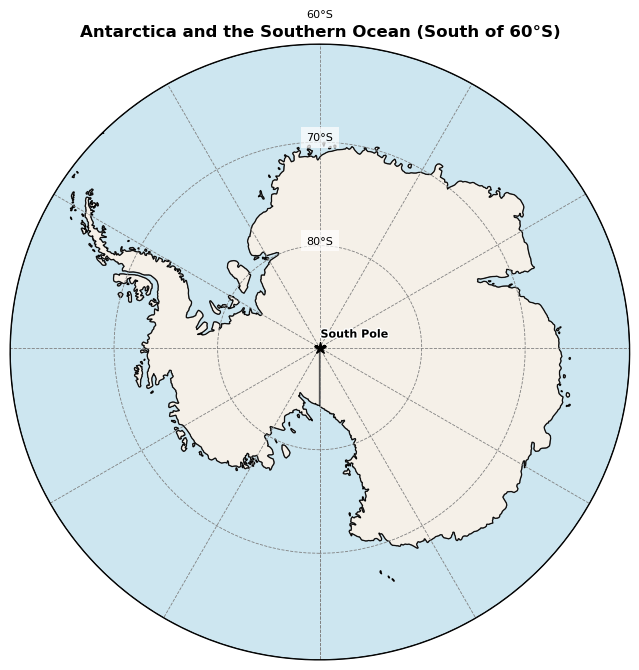

In [39]:

fig1 = plt.figure(figsize=(8, 8))
ax1 = plt.axes(projection=ccrs.SouthPolarStereo())

ax1.set_extent([-180, 180, -90, -60], crs=ccrs.PlateCarree())

# Circular map boundary 
theta = np.linspace(0, 2*np.pi, 200)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T

ax1.set_boundary(Path(verts * radius + center), transform=ax1.transAxes)

circle = mpatches.Circle(
    center, radius, transform=ax1.transAxes,
    facecolor='none', edgecolor='black', linewidth=1.2, zorder=5
)
ax1.add_patch(circle)

# Map layers
ax1.add_feature(cfeature.OCEAN.with_scale('50m'), color='#cde6f0')
ax1.add_feature(cfeature.LAND.with_scale('50m'),
                facecolor='#f5f0e8', edgecolor='#555555')
ax1.coastlines(resolution='50m', linewidth=0.6)

#  Gridlines 
gl1 = ax1.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=False,
    linestyle='--',
    linewidth=0.6,
    color='gray'
)
gl1.xlocator = mticker.FixedLocator(range(-180, 181, 30))
gl1.ylocator = mticker.FixedLocator([-90, -80, -70, -60])

# Latitude labels 
lat_label_positions = {
    -80: -80,
    -70: -70,
    -60: -58.5   # slightly north of the boundary so it is visible
}

for true_lat, plot_lat in lat_label_positions.items():
    ax1.text(
        0, plot_lat,
        f"{abs(true_lat)}°S",
        transform=ccrs.Geodetic(),
        ha='center',
        va='bottom',
        fontsize=8,
        bbox=dict(facecolor='white', alpha=0.7, lw=0),
        zorder=6
    )
# South Pole 
ax1.plot(0, -90, marker='*', color='black', markersize=9,
         transform=ccrs.Geodetic())
ax1.text(
    5, -89, "South Pole",
    transform=ccrs.Geodetic(),
    fontsize=8, fontweight='bold',
    path_effects=[pe.withStroke(linewidth=2, foreground="white")]
)

# Title
ax1.set_title(
    "Antarctica and the Southern Ocean (South of 60°S)",
    fontsize=12, fontweight='bold'
)

plt.savefig("figures/map1_antarctica.png", dpi=200, bbox_inches="tight")
plt.show()


# Exercise 2: Map 2. South Atlantic Ocean (20°S–50°S)

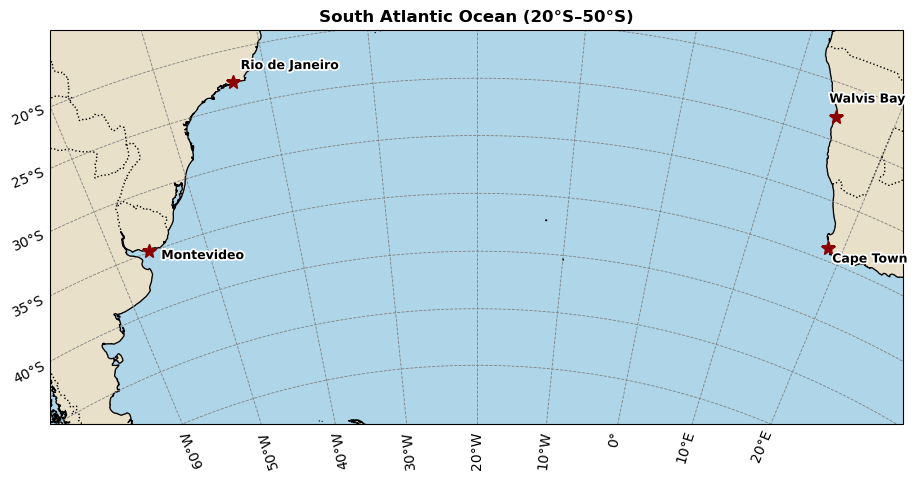

In [35]:
# Domain
west, east, south, north = -60, 20, -50, -20

projection = ccrs.AlbersEqualArea(
    central_longitude=(west + east) / 2,
    central_latitude=(south + north) / 2,
    standard_parallels=(-25, -45)
)

fig2, ax2 = plt.subplots(
    figsize=(11, 8),
    subplot_kw={'projection': projection}
)

ax2.set_extent([west, east, south, north], crs=ccrs.PlateCarree())

#  Basemap 
ax2.add_feature(cfeature.OCEAN.with_scale('50m'), color='#aed6e8')
ax2.add_feature(cfeature.LAND.with_scale('50m'),
                facecolor='#e8e0c8', edgecolor='gray')
ax2.coastlines(resolution='10m', linewidth=0.8)
ax2.add_feature(cfeature.BORDERS, linestyle=':')

#  Gridlines with labels
gl2 = ax2.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=True,
    linestyle='--',
    linewidth=0.6,
    color='gray'
)
gl2.top_labels = False
gl2.right_labels = False
gl2.xlocator = mticker.FixedLocator(range(-60, 25, 10))
gl2.ylocator = mticker.FixedLocator(range(-50, -15, 5))

# City markers and labels 
label_offsets = {
    "Walvis Bay": (-1, 1),
    "Cape Town": (1, -1),
    "Rio de Janeiro": (1, 1),
    "Montevideo": (1, -1)
}

for city, (lon, lat) in cities.items():
    ax2.plot(
        lon, lat, marker='*',
        markersize=10, color='darkred',
        transform=ccrs.Geodetic()
    )

    dx, dy = label_offsets[city]
    ax2.text(
        lon + dx, lat + dy, city,
        transform=ccrs.Geodetic(),
        fontsize=9, fontweight='bold',
        path_effects=[pe.withStroke(linewidth=2.5, foreground='white')]
    )

# Title 
ax2.set_title(
    "South Atlantic Ocean (20°S–50°S)",
    fontsize=12, fontweight='bold'
)

plt.savefig("figures/map2_south_atlantic.png", dpi=200, bbox_inches="tight")
plt.show()